## Biblioteki

In [139]:
import os
import time
import pickle
import gzip
import warnings
from itertools import product
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.transforms import v2
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.base import clone
import umap
from sklearn import preprocessing as pp
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles, make_gaussian_quantiles, make_classification, load_digits
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap, MDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')

## Funkcja oceny

In [201]:
def evaluate_reduction(reducer,classifier,X_train,X_test,y_train,y_test,name):
    start = time.time()
    if name == "LDA":
        X_train_red = reducer.fit_transform(X_train,y_train)
    else:
        X_train_red = reducer.fit_transform(X_train)

    X_test_red = reducer.transform(X_test)
    model = clone(classifier)
    model.fit(X_train_red,y_train)

    y_pred = model.predict(X_test_red)
    elapsed = time.time() - start
    
    return {
        "Method": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "F1": f1_score(
            y_test,
            y_pred
        ),
        "Time": elapsed
    }

In [141]:
def evaluate_mds(n_components,classifier,X,y):
    start = time.time()
    
    X_mds = MDS(n_components=n_components,random_state=42).fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_mds,y,test_size=0.2,stratify=y,random_state=42)
    model = clone(classifier)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    return {
        "Method": "MDS",
        "Components": n_components,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Time": elapsed
    }

## Funkcja do wykresów

In [142]:
import matplotlib.pyplot as plt

def plot_embedding(X_embedded, y, title):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(X_embedded[:, 0],X_embedded[:, 1],c=y,cmap="coolwarm",alpha=0.8)

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)

    plt.colorbar(scatter, label="Diabetes")

    plt.tight_layout()
    plt.show()

# PIMA

Zbiór Pima Indians Diabetes zawiera dane medyczne pacjentów oraz informację o występowaniu cukrzycy. Celem jest porównanie wpływu różnych metod redukcji wymiarowości na jakość klasyfikacji oraz wizualizację danych.

In [143]:
indians = pd.read_csv(r"C:\Users\Mikolaj\diabetes.csv")
X = indians.drop(columns=["Outcome"])
y = indians["Outcome"]

Dane dzielone są na zbiór treningowy i testowy. Następnie wykonywana jest standaryzacja cech, aby wszystkie zmienne miały porównywalną skalę.

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [145]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Analiza wpływu parametrów na jakość klasyfikacji

## Baseline

Jako punkt odniesienia wykorzystano klasyfikator SVM uczony na oryginalnych danych bez redukcji wymiarowości.

In [146]:
param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 10, 100],
        "gamma": [0.001, 0.01, 0.1, 1]
    }
]

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid.best_params_)

print("\nNajlepszy wynik CV:")
print(grid.best_score_)

Najlepsze parametry:
{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}

Najlepszy wynik CV:
0.6403188946293594


In [147]:
best_svm = grid.best_estimator_

start = time.time()

best_svm.fit(X_train, y_train)

y_pred = best_svm.predict(X_test)

baseline = {
    "Method": "Baseline",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Time": time.time() - start
}

results=[]
results.append({
    "Method": "Baseline",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
})

W celu porównania Accuracy i F1 dla metod redukcji wymiarowości zdecydowaliśmy się na redukcję zbioru PIMA do 5 wymiarów.

In [148]:
results_2d = []
results_5d = []
results_2d.insert(0, baseline.copy())
results_5d.insert(0, baseline.copy())

## PCA

PCA jest liniową metodą redukcji wymiarowości. Nowe zmienne powstają jako kombinacje liniowe oryginalnych cech i maksymalizują wyjaśnianą wariancję danych.

Najpierw analizujemy wpływ liczby komponentów na jakość klasyfikacji. Następnie wybieramy wartość `n_components = 5`, która będzie wykorzystywana w końcowym porównaniu metod.

In [149]:
pca_results = []

for n in range(2, 9):
    result = evaluate_reduction(PCA(n_components=n), best_svm, X_train, X_test, y_train, y_test, "PCA")
    
    result["n_components"] = n

    pca_results.append(result)

    if n == 2:
        results_2d.append(result.copy())

    if n == 5:
        results_5d.append(result.copy())

pca_results = pd.DataFrame(pca_results)

pca_results

,Method,Accuracy,F1,Time,n_components
0,PCA,0.714286,0.551020,0.012966,2
1,PCA,0.707792,0.526316,0.015124,3
2,PCA,0.675325,0.456522,0.013277,4
3,PCA,0.720779,0.516854,0.013623,5
4,PCA,0.733766,0.585859,0.013237,6
5,PCA,0.727273,0.580000,0.012921,7
6,PCA,0.714286,0.551020,0.012583,8


In [150]:
results_2d

[{'Method': 'Baseline',
  'Accuracy': 0.7142857142857143,
  'F1': 0.5510204081632653,
  'Time': 0.020786046981811523},
 {'Method': 'PCA',
  'Accuracy': 0.7142857142857143,
  'F1': 0.5510204081632653,
  'Time': 0.012965917587280273,
  'n_components': 2}]

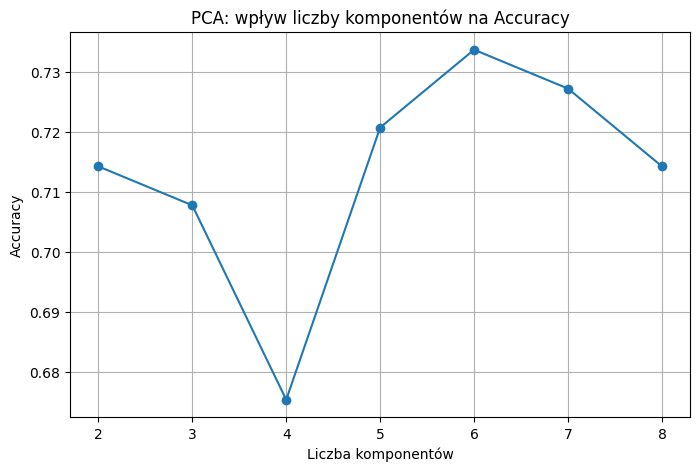

In [151]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_results["n_components"],
    pca_results["Accuracy"],
    marker="o"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Accuracy")
plt.title("PCA: wpływ liczby komponentów na Accuracy")

plt.grid(True)
plt.show()

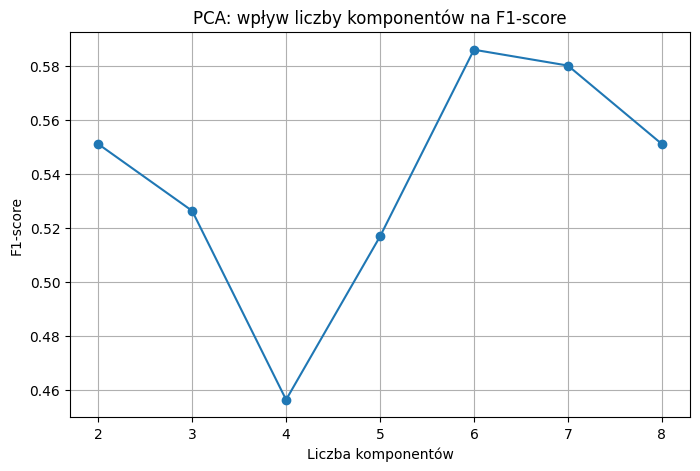

In [152]:
plt.figure(figsize=(8, 5))

plt.plot(
    pca_results["n_components"],
    pca_results["F1"],
    marker="o"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("F1-score")
plt.title("PCA: wpływ liczby komponentów na F1-score")

plt.grid(True)
plt.show()

## UMAP

UMAP jest nieliniową metodą redukcji wymiarowości opartą na idei rozmaitości. Metoda stara się zachować lokalną strukturę danych przy jednoczesnym tworzeniu niskowymiarowej reprezentacji.

Dla UMAP analizujemy wpływ liczby komponentów, a następnie badamy wpływ parametrów `n_neighbors` i `min_dist` przy ustalonej liczbie wymiarów równej 5.

In [153]:
umap_results = []

for n in range(2, 9):

    result = evaluate_reduction(umap.UMAP(n_components=n, random_state=42), best_svm, X_train, X_test, y_train, y_test, "UMAP")
    result["n_components"] = n
    umap_results.append(result)

umap_results = pd.DataFrame(umap_results)

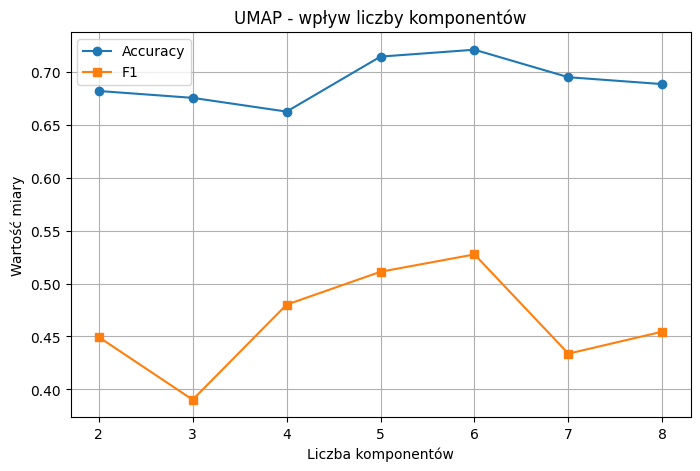

In [154]:
plt.figure(figsize=(8, 5))

plt.plot(
    umap_results["n_components"],
    umap_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    umap_results["n_components"],
    umap_results["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Wartość miary")
plt.title("UMAP - wpływ liczby komponentów")

plt.legend()
plt.grid(True)

plt.show()

In [155]:
neighbors_grid = [5, 10, 20, 50]
min_dist_grid = [0.0, 0.1, 0.3, 0.5]

In [156]:
umap_tuning = []

for n_neighbors in neighbors_grid:
    for min_dist in min_dist_grid:

        result = evaluate_reduction(
            umap.UMAP(
                n_components=5,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                random_state=42
            ),
            best_svm,
            X_train,
            X_test,
            y_train,
            y_test,
            "UMAP"
        )

        result["n_neighbors"] = n_neighbors
        result["min_dist"] = min_dist

        umap_tuning.append(result)

umap_tuning = pd.DataFrame(umap_tuning)

Heatmapa przedstawia jakość klasyfikacji dla różnych konfiguracji parametrów UMAP. Pozwala wybrać ustawienia wykorzystywane w dalszej części analizy.

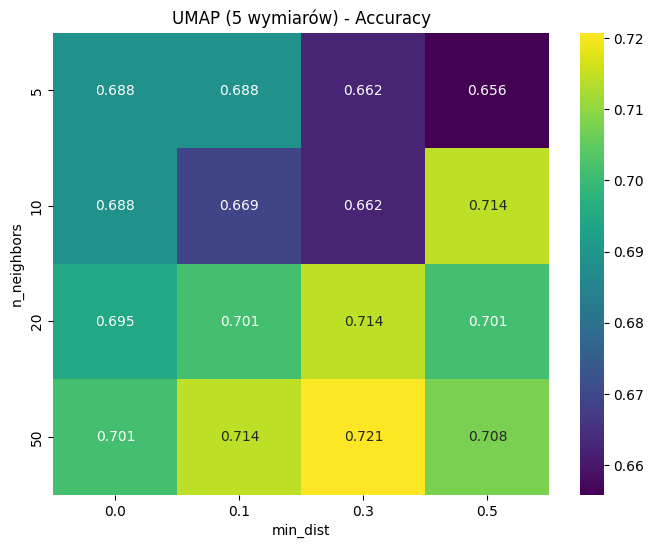

In [157]:
import seaborn as sns

pivot = umap_tuning.pivot(
    index="n_neighbors",
    columns="min_dist",
    values="Accuracy"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title("UMAP (5 wymiarów) - Accuracy")

plt.show()

In [158]:
best_row = umap_tuning.loc[
    umap_tuning["Accuracy"].idxmax()
]
best_row

Method             UMAP
Accuracy       0.720779
F1             0.505747
Time           1.872142
n_neighbors          50
min_dist            0.3
Name: 14, dtype: object

In [159]:
best_umap_neighbors = best_row["n_neighbors"]
best_umap_min_dist = best_row["min_dist"]

In [160]:
umap_2d = evaluate_reduction(
    umap.UMAP(
        n_components=2,
        n_neighbors=best_umap_neighbors,
        min_dist=best_umap_min_dist,
        random_state=42
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "UMAP"
)

results_2d.append(umap_2d)

In [161]:
umap_5d = evaluate_reduction(
    umap.UMAP(
        n_components=5,
        n_neighbors=best_umap_neighbors,
        min_dist=best_umap_min_dist,
        random_state=42
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "UMAP"
)

results_5d.append(umap_5d)

In [162]:
X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=best_umap_neighbors,
    min_dist=best_umap_min_dist,
    random_state=42
).fit_transform(X_train)

## Kernel PCA

Kernel PCA rozszerza klasyczne PCA o zastosowanie funkcji jądra. Dzięki temu możliwe jest uchwycenie nieliniowych zależności występujących w danych.

W pierwszym kroku badamy wpływ liczby komponentów. Następnie dobieramy parametr `gamma` jądra RBF dla reprezentacji pięciowymiarowej.

In [163]:
gamma = 0.1
kernel = "rbf"

In [164]:
from sklearn.decomposition import KernelPCA

kpca_results = []

for n in range(2, 9):

    result = evaluate_reduction(
        KernelPCA(
            n_components=n,
            kernel="rbf",
            gamma=0.1
        ),
        best_svm,
        X_train,
        X_test,
        y_train,
        y_test,
        "Kernel PCA"
    )

    result["n_components"] = n

    kpca_results.append(result)

kpca_results = pd.DataFrame(kpca_results)

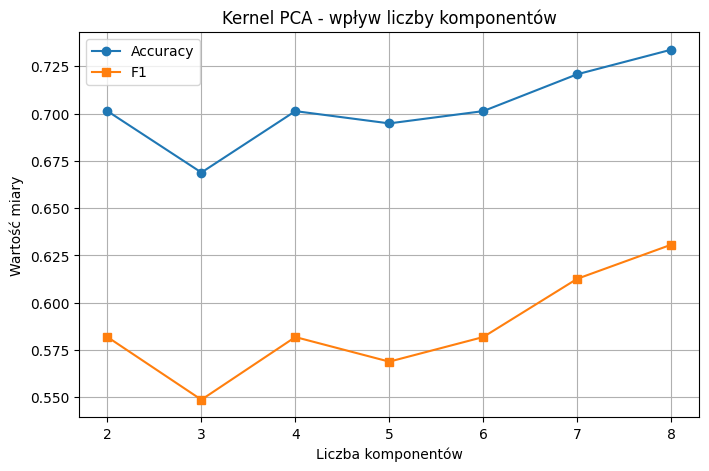

In [165]:
plt.figure(figsize=(8, 5))

plt.plot(
    kpca_results["n_components"],
    kpca_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    kpca_results["n_components"],
    kpca_results["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Wartość miary")
plt.title("Kernel PCA - wpływ liczby komponentów")

plt.legend()
plt.grid(True)

plt.show()

In [166]:
gamma_grid = [0.001,0.01,0.1,1,10]

In [167]:
kpca_tuning = []

for gamma in gamma_grid:

    result = evaluate_reduction(
        KernelPCA(
            n_components=5,
            kernel="rbf",
            gamma=gamma
        ),
        best_svm,
        X_train,
        X_test,
        y_train,
        y_test,
        "Kernel PCA"
    )

    result["gamma"] = gamma

    kpca_tuning.append(result)

kpca_tuning = pd.DataFrame(kpca_tuning)

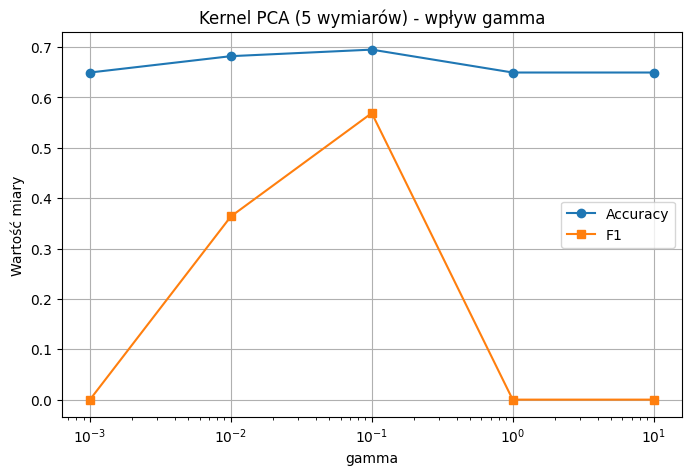

In [168]:
plt.figure(figsize=(8, 5))

plt.plot(
    kpca_tuning["gamma"],
    kpca_tuning["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    kpca_tuning["gamma"],
    kpca_tuning["F1"],
    marker="s",
    label="F1"
)

plt.xscale("log")

plt.xlabel("gamma")
plt.ylabel("Wartość miary")

plt.title(
    "Kernel PCA (5 wymiarów) - wpływ gamma"
)

plt.legend()
plt.grid(True)

plt.show()

In [169]:
best_kpca_gamma = kpca_tuning.loc[
    kpca_tuning["Accuracy"].idxmax(),
    "gamma"
]

In [170]:
kpca_2d = evaluate_reduction(
    KernelPCA(
        n_components=2,
        kernel="rbf",
        gamma=best_kpca_gamma
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Kernel PCA"
)

results_2d.append(kpca_2d)

kpca_5d = evaluate_reduction(
    KernelPCA(
        n_components=5,
        kernel="rbf",
        gamma=best_kpca_gamma
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Kernel PCA"
)

results_5d.append(kpca_5d)

X_kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=best_kpca_gamma
).fit_transform(X_train)



## Isomap

Isomap jest metodą uczenia rozmaitości zachowującą odległości geodezyjne pomiędzy obserwacjami. Pozwala wykrywać nieliniową strukturę danych.

Analizujemy wpływ liczby komponentów oraz parametru `n_neighbors`, który określa liczbę sąsiadów wykorzystywanych podczas budowy grafu.

In [171]:
from sklearn.manifold import Isomap

isomap_results = []

for n in range(2, 9):

    result = evaluate_reduction(
        Isomap(
            n_components=n,
            n_neighbors=5
        ),
        best_svm,
        X_train,
        X_test,
        y_train,
        y_test,
        "Isomap"
    )

    result["n_components"] = n

    isomap_results.append(result)

isomap_results = pd.DataFrame(isomap_results)

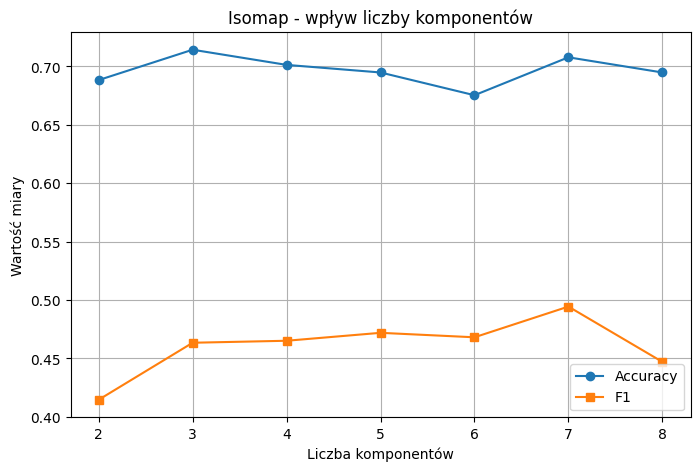

In [172]:
plt.figure(figsize=(8, 5))

plt.plot(
    isomap_results["n_components"],
    isomap_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    isomap_results["n_components"],
    isomap_results["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Wartość miary")
plt.title("Isomap - wpływ liczby komponentów")

plt.legend()
plt.grid(True)

plt.show()

In [173]:
neighbors_grid = [3, 5, 10, 20, 50]

In [174]:
isomap_tuning = []

for n_neighbors in neighbors_grid:

    result = evaluate_reduction(
        Isomap(
            n_components=5,
            n_neighbors=n_neighbors
        ),
        best_svm,
        X_train,
        X_test,
        y_train,
        y_test,
        "Isomap"
    )

    result["n_neighbors"] = n_neighbors

    isomap_tuning.append(result)

isomap_tuning = pd.DataFrame(isomap_tuning)

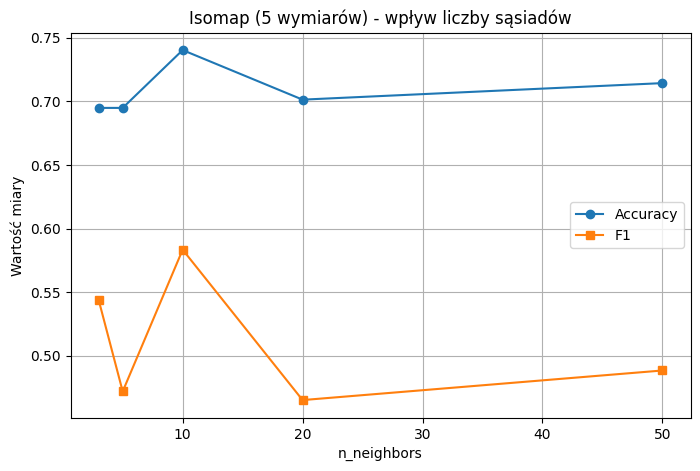

In [175]:
plt.figure(figsize=(8, 5))

plt.plot(
    isomap_tuning["n_neighbors"],
    isomap_tuning["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    isomap_tuning["n_neighbors"],
    isomap_tuning["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("n_neighbors")
plt.ylabel("Wartość miary")

plt.title(
    "Isomap (5 wymiarów) - wpływ liczby sąsiadów"
)

plt.legend()
plt.grid(True)

plt.show()

In [176]:
best_iso_neighbors = isomap_tuning.loc[
    isomap_tuning["Accuracy"].idxmax(),
    "n_neighbors"
]

In [177]:
isomap_2d = evaluate_reduction(
    Isomap(
        n_components=2,
        n_neighbors=best_iso_neighbors
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Isomap"
)

results_2d.append(isomap_2d)

isomap_5d = evaluate_reduction(
    Isomap(
        n_components=5,
        n_neighbors=best_iso_neighbors
    ),
    best_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Isomap"
)

results_5d.append(isomap_5d)

## MDS

MDS redukuje wymiarowość danych w taki sposób, aby możliwie dobrze zachować odległości pomiędzy obserwacjami w nowej przestrzeni.

Dla MDS analizujemy wyłącznie wpływ liczby komponentów, ponieważ metoda nie posiada istotnych hiperparametrów wpływających na jakość odwzorowania.

In [178]:
mds_results = []

for n in range(2, 9):
    result = evaluate_mds(
        n_components=n,
        classifier=best_svm,
        X=X_scaled,
        y=y
    )

    result["n_components"] = n

    mds_results.append(result)

mds_results = pd.DataFrame(mds_results)

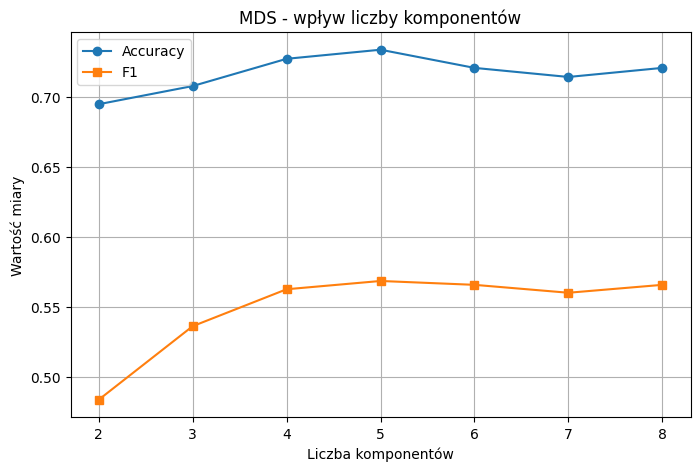

In [179]:
plt.figure(figsize=(8, 5))

plt.plot(
    mds_results["n_components"],
    mds_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    mds_results["n_components"],
    mds_results["F1"],
    marker="s",
    label="F1"
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Wartość miary")
plt.title("MDS - wpływ liczby komponentów")

plt.legend()
plt.grid(True)

plt.show()

In [180]:
mds_2d = mds_results[
    mds_results["n_components"] == 2
].iloc[0].to_dict()

results_2d.append(mds_2d)

In [181]:
mds_5d = mds_results[
    mds_results["n_components"] == 5
].iloc[0].to_dict()

results_5d.append(mds_5d)

In [182]:
results_2d = pd.DataFrame(results_2d)
results_5d = pd.DataFrame(results_5d)

## Tabela wyników dla redukcji do 2 i 5 wymiarów

Porównano skuteczność klasyfikatora SVM po zastosowaniu różnych metod redukcji wymiarowości. Ocenę przeprowadzono przy użyciu miar Accuracy oraz F1-score.

In [183]:
results_2d = pd.DataFrame(results_2d)
results_5d = pd.DataFrame(results_5d)

results_2d = results_2d[
    ["Method", "Accuracy", "F1", "Time"]
]

results_5d = results_5d[
    ["Method", "Accuracy", "F1", "Time"]
]

results_2d

,Method,Accuracy,F1,Time
0,Baseline,0.714286,0.551020,0.020786
1,PCA,0.714286,0.551020,0.012966
2,UMAP,0.668831,0.370370,1.677061
3,Kernel PCA,0.701299,0.581818,0.027106
4,Isomap,0.668831,0.354430,0.092852
5,MDS,0.694805,0.483516,14.519643


W przypadku redukcji do dwóch wymiarów najlepsze wyniki uzyskało PCA, osiągając identyczne wartości Accuracy i F1 jak model bazowy. Oznacza to, że większość informacji istotnej dla klasyfikacji została zachowana już w dwóch pierwszych składowych głównych. Kernel PCA uzyskało nieco niższe Accuracy, ale najwyższą wartość F1 spośród metod redukcji wymiarowości. UMAP, Isomap i MDS osiągnęły słabsze wyniki, przy czym MDS wymagał zdecydowanie najdłuższego czasu obliczeń.

In [184]:
results_5d

,Method,Accuracy,F1,Time
0,Baseline,0.714286,0.551020,0.020786
1,PCA,0.720779,0.516854,0.013623
2,UMAP,0.720779,0.505747,1.764625
3,Kernel PCA,0.694805,0.568807,0.027589
4,Isomap,0.740260,0.583333,0.084601
5,MDS,0.733766,0.568421,14.676872


Przy redukcji do pięciu wymiarów wszystkie analizowane metody osiągnęły wyniki porównywalne lub lepsze od modelu bazowego. Najwyższe wartości Accuracy oraz F1 uzyskał Isomap, co sugeruje, że zachowanie nieliniowej struktury danych może być korzystne dla tego zbioru. Dobre wyniki osiągnął również MDS, jednak kosztem znacznie dłuższego czasu obliczeń. PCA oraz UMAP uzyskały Accuracy nieco wyższe od modelu bazowego, natomiast Kernel PCA osiągnęło najwyższy F1 spośród metod o krótkim czasie działania. Wyniki wskazują, że przy zachowaniu pięciu wymiarów redukcja nie prowadzi do utraty istotnej informacji, a w niektórych przypadkach może nawet poprawić skuteczność klasyfikacji.

## Wnioski

Dla zbioru Pima Indians Diabetes redukcja wymiarowości nie prowadziła do istotnego pogorszenia jakości klasyfikacji. Już przy dwóch wymiarach metoda PCA osiągnęła wyniki porównywalne z modelem bazowym, co wskazuje na obecność dużej ilości informacji w pierwszych składowych głównych.

Zwiększenie liczby wymiarów do pięciu poprawiło wyniki większości metod. Najlepszą skuteczność osiągnął Isomap, uzyskując najwyższe wartości Accuracy i F1 spośród analizowanych metod. Dobre wyniki osiągnęły również MDS oraz Kernel PCA, jednak MDS wymagał znacznie większego czasu obliczeń.

Analiza wpływu hiperparametrów pokazała, że odpowiedni dobór parametrów może istotnie wpływać na skuteczność metod nieliniowych. Jednocześnie różnice pomiędzy najlepszymi konfiguracjami poszczególnych metod okazały się stosunkowo niewielkie.

Otrzymane wyniki sugerują, że dla zbioru Pima Indians Diabetes redukcja wymiarowości do około pięciu komponentów pozwala zachować większość informacji istotnej dla klasyfikacji, a wybór konkretnej metody ma mniejsze znaczenie niż liczba zachowanych wymiarów.

## Wykresy

Poniżej przedstawiono dwuwymiarowe reprezentacje danych uzyskane za pomocą poszczególnych metod redukcji wymiarowości.

In [185]:
X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])

In [186]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, MDS
import umap

X_pca = PCA(
    n_components=2
).fit_transform(X)

X_kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=best_kpca_gamma
).fit_transform(X)

X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=best_umap_neighbors,
    min_dist=best_umap_min_dist,
    random_state=42
).fit_transform(X)

X_isomap = Isomap(
    n_components=2,
    n_neighbors=best_iso_neighbors
).fit_transform(X)

X_mds = MDS(
    n_components=2,
    random_state=42,
    n_init=4
).fit_transform(X)

In [187]:
embeddings = {
    "PCA": X_pca,
    "UMAP": X_umap,
    "Kernel PCA": X_kpca,
    "Isomap": X_isomap,
    "MDS": X_mds
}

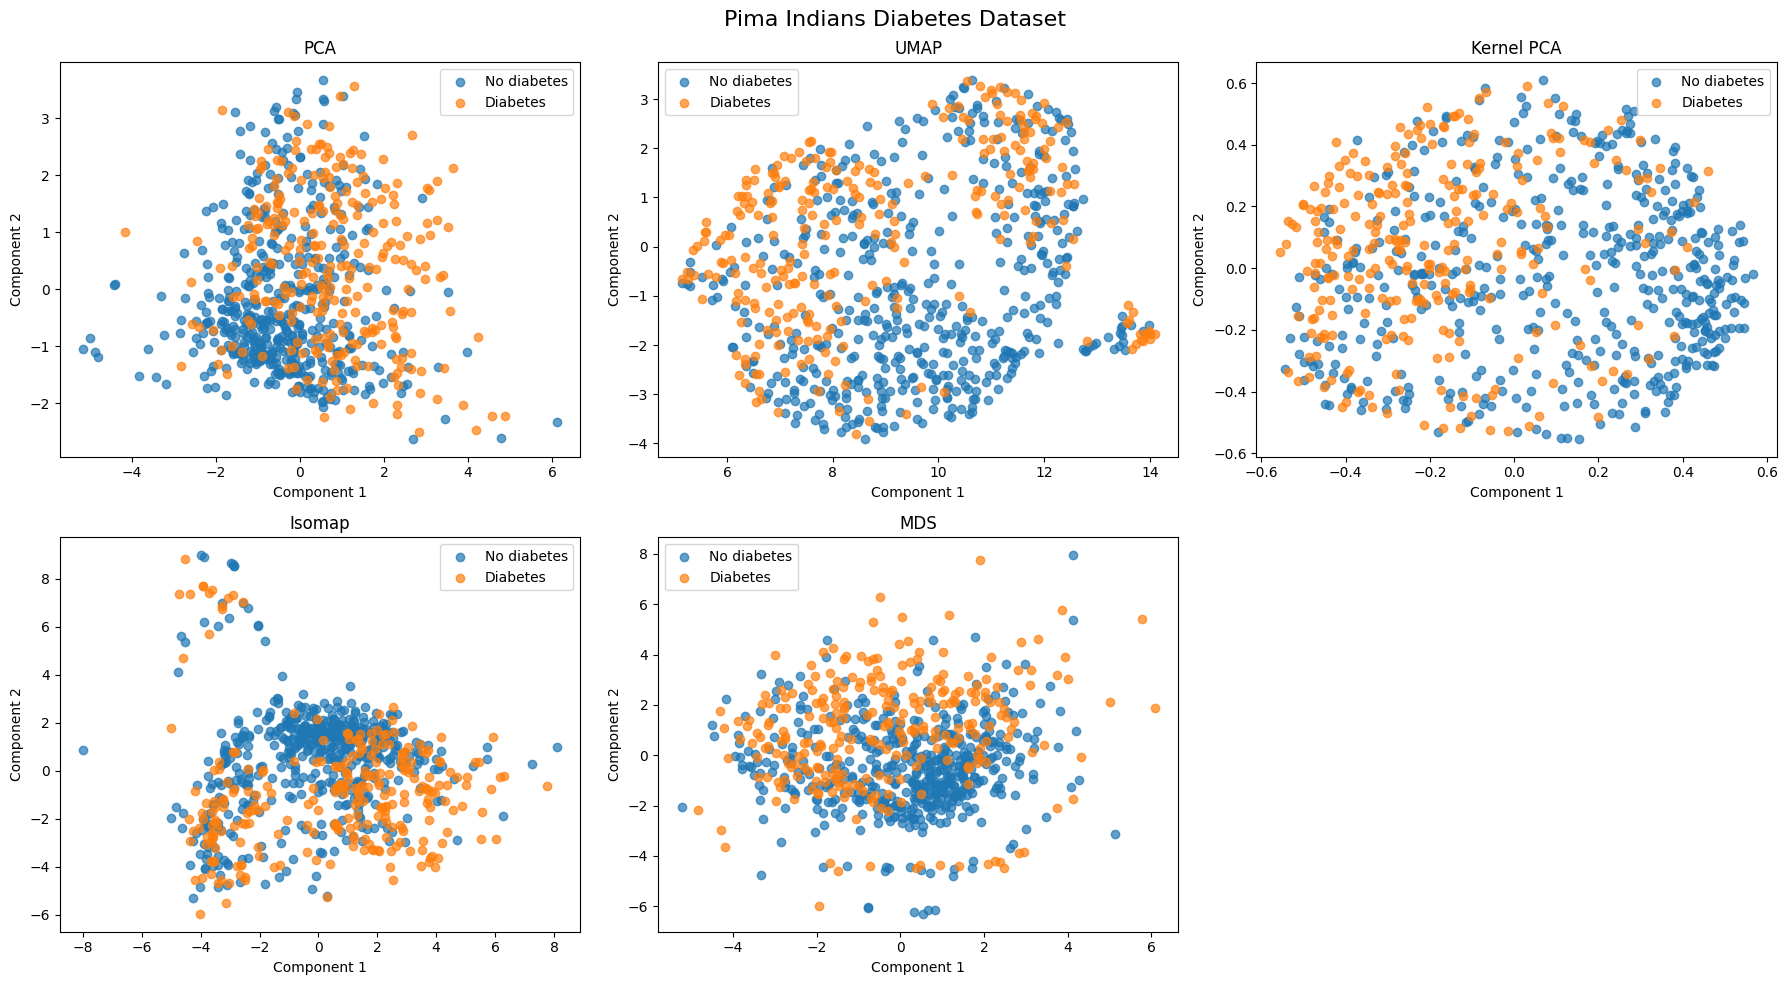

In [188]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

for ax, (name, embedding) in zip(
    axes.ravel(),
    embeddings.items()
):

    ax.scatter(
        embedding[y == 0, 0],
        embedding[y == 0, 1],
        alpha=0.7,
        label="No diabetes"
    )

    ax.scatter(
        embedding[y == 1, 0],
        embedding[y == 1, 1],
        alpha=0.7,
        label="Diabetes"
    )

    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

    ax.legend()

axes[1, 2].axis("off")

plt.suptitle(
    "Pima Indians Diabetes Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Analiza wizualizacji

Widoczne jest znaczne nakładanie się klas dla wszystkich metod redukcji wymiarowości, co sugeruje brak wyraźnej separacji przypadków cukrzycy i jej braku w przestrzeni dwuwymiarowej. Jest to zgodne z wynikami klasyfikacji, które pozostają na umiarkowanym poziomie niezależnie od zastosowanej metody.

UMAP i Isomap zachowują bardziej złożoną, nieliniową strukturę danych, tworząc wyraźne skupiska obserwacji. Pomimo atrakcyjnej wizualizacji nie prowadzi to jednak do jednoznacznego rozdzielenia klas. PCA, Kernel PCA oraz MDS generują bardziej zwarte reprezentacje, w których również obserwujemy silne nakładanie się punktów obu klas.

Brak wyraźnej separacji na wykresach wskazuje, że trudność klasyfikacji wynika przede wszystkim ze struktury danych, a nie z ograniczeń konkretnej metody redukcji wymiarowości.

# MNIST

MNIST jest jednym z najczęściej wykorzystywanych zbiorów danych w uczeniu maszynowym. Zawiera obrazy odręcznie zapisanych cyfr od 0 do 9 o rozmiarze 28×28 pikseli.

In [194]:
mnist_train = datasets.MNIST(
    root="data",
    train=True,
    download=True
)

mnist_test = datasets.MNIST(
    root="data",
    train=False,
    download=True
)

In [195]:
X_train_raw = mnist_train.data.numpy()
X_test_raw = mnist_test.data.numpy()

y_train = mnist_train.targets.numpy()
y_test = mnist_test.targets.numpy()

In [196]:
X_train = X_train_raw.reshape(
    len(X_train_raw),
    28 * 28
)

X_test = X_test_raw.reshape(
    len(X_test_raw),
    28 * 28
)

In [197]:
X_train, _, y_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

In [198]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Baseline

In [220]:
import time
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC # Przykładowy domyślny klasyfikator

def evaluate_reduction(reducer, X_train, X_test, y_train, y_test, name, classifier=SVC()):
    start = time.time()
    
    if name == "LDA":
        X_train_red = reducer.fit_transform(X_train, y_train)
    else:
        X_train_red = reducer.fit_transform(X_train)

    X_test_red = reducer.transform(X_test)
    model = clone(classifier)
    model.fit(X_train_red, y_train)

    y_pred = model.predict(X_test_red)
    elapsed = time.time() - start
    
    return {
        "Method": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred, average='weighted'), 
        "Time": elapsed
    }

## PCA

In [221]:
results_mnist.append(
    evaluate_reduction(
        PCA(n_components=9), 
        X_train_scaled,      
        X_test_scaled,       
        y_train,             
        y_test,              
        "PCA"                
    )
)

## Kernel PCA

In [222]:
results_mnist.append(
    evaluate_reduction(
        KernelPCA(
            n_components=9,
            kernel="rbf"
        ),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "Kernel PCA"
    )
)

## Isomap

In [223]:
results_mnist.append(
    evaluate_reduction(
        Isomap(
            n_components=9
        ),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "Isomap"
    )
)

## UMAP

In [224]:
results_mnist.append(
    evaluate_reduction(
        umap.UMAP(
            n_components=9,
            random_state=42
        ),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "UMAP"
    )
)

## LDA

In [225]:
results_mnist.append(
    evaluate_reduction(
        LinearDiscriminantAnalysis(
            n_components=9
        ),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        "LDA"
    )
)

W celu porównania metod na zbiorze MNIST zastosowanliśmy redukcję do 9 wymiarów z uwagi na fakt, że jest to górne ograniczenie dla metody LDA. Zrezygnowaliśmy tutaj z badania metody MDS ze względu na wysoki koszt obliczeniowy.

In [226]:
results_mnist_df = pd.DataFrame(
    results_mnist
)

results_mnist_df

,Method,Accuracy,F1,Time
0,Kernel PCA,0.8608,0.861345,10.526996
1,Isomap,0.8890,0.888583,25.124135
2,LDA,0.8906,0.890190,3.469147
3,PCA,0.8841,0.883907,4.408545
4,PCA,0.8841,0.883907,4.263201
5,Kernel PCA,0.8608,0.861345,11.190511
6,Isomap,0.8890,0.888583,25.107774
7,UMAP,0.8662,0.865598,54.516236
8,LDA,0.8906,0.890190,3.193218


### Wnioski

Najwyższą skuteczność klasyfikacji osiągnął model bazowy wykorzystujący pełną reprezentację danych (Accuracy = 0.941, F1 = 0.941). Oznacza to, że oryginalne 784 cechy zawierają istotne informacje, których częściowo nie da się zachować po redukcji wymiarowości.

Spośród analizowanych metod redukcji wymiarowości najlepsze wyniki uzyskał LDA (Accuracy = 0.891, F1 = 0.890). Wynik ten jest zgodny z oczekiwaniami, ponieważ LDA jest metodą nadzorowaną i podczas wyznaczania nowych wymiarów wykorzystuje informacje o klasach.

Bardzo dobre rezultaty osiągnęły również Isomap (Accuracy = 0.889) oraz PCA (Accuracy = 0.884). Oznacza to, że nawet po redukcji z 784 do 9 wymiarów możliwe jest zachowanie większości informacji potrzebnych do poprawnej klasyfikacji cyfr.

Kernel PCA oraz UMAP uzyskały nieco słabsze wyniki klasyfikacyjne. W badanym przypadku bardziej złożone metody nieliniowe nie przyniosły poprawy względem klasycznego PCA.

Pod względem czasu obliczeń najszybszymi metodami były PCA oraz LDA. Metody Isomap i UMAP wymagały znacznie większych nakładów obliczeniowych, przy czym UMAP był najwolniejszą z analizowanych metod redukcji wymiarowości.

Uzyskane wyniki pokazują, że dla zadania klasyfikacji cyfr możliwe jest bardzo silne zmniejszenie liczby wymiarów danych przy stosunkowo niewielkiej utracie jakości klasyfikacji. Szczególnie skuteczne okazały się metody PCA, Isomap oraz LDA.

### Wykresy
Poniższe wykresy przedstawiają dwuwymiarowe reprezentacje obrazów cyfr uzyskane przy użyciu różnych metod redukcji wymiarowości.

In [227]:
X_pca = PCA(
    n_components=2
).fit_transform(X_train_scaled)

X_umap = umap.UMAP(
    n_components=2,
    random_state=42
).fit_transform(X_train_scaled)

X_lda = LinearDiscriminantAnalysis(
    n_components=2
).fit_transform(
    X_train_scaled,
    y_train
)

X_tsne = TSNE(
    n_components=2,
    random_state=42
).fit_transform(X_train_scaled)

X_kpca = KernelPCA(
    n_components=2,
    kernel="rbf"
).fit_transform(X_train_scaled)

X_isomap = Isomap(
    n_components=2
).fit_transform(X_train_scaled)

In [228]:
embeddings = {
    "PCA": X_pca,
    "Kernel PCA": X_kpca,
    "LDA": X_lda,
    "UMAP": X_umap,
    "Isomap": X_isomap,
    "t-SNE": X_tsne
}

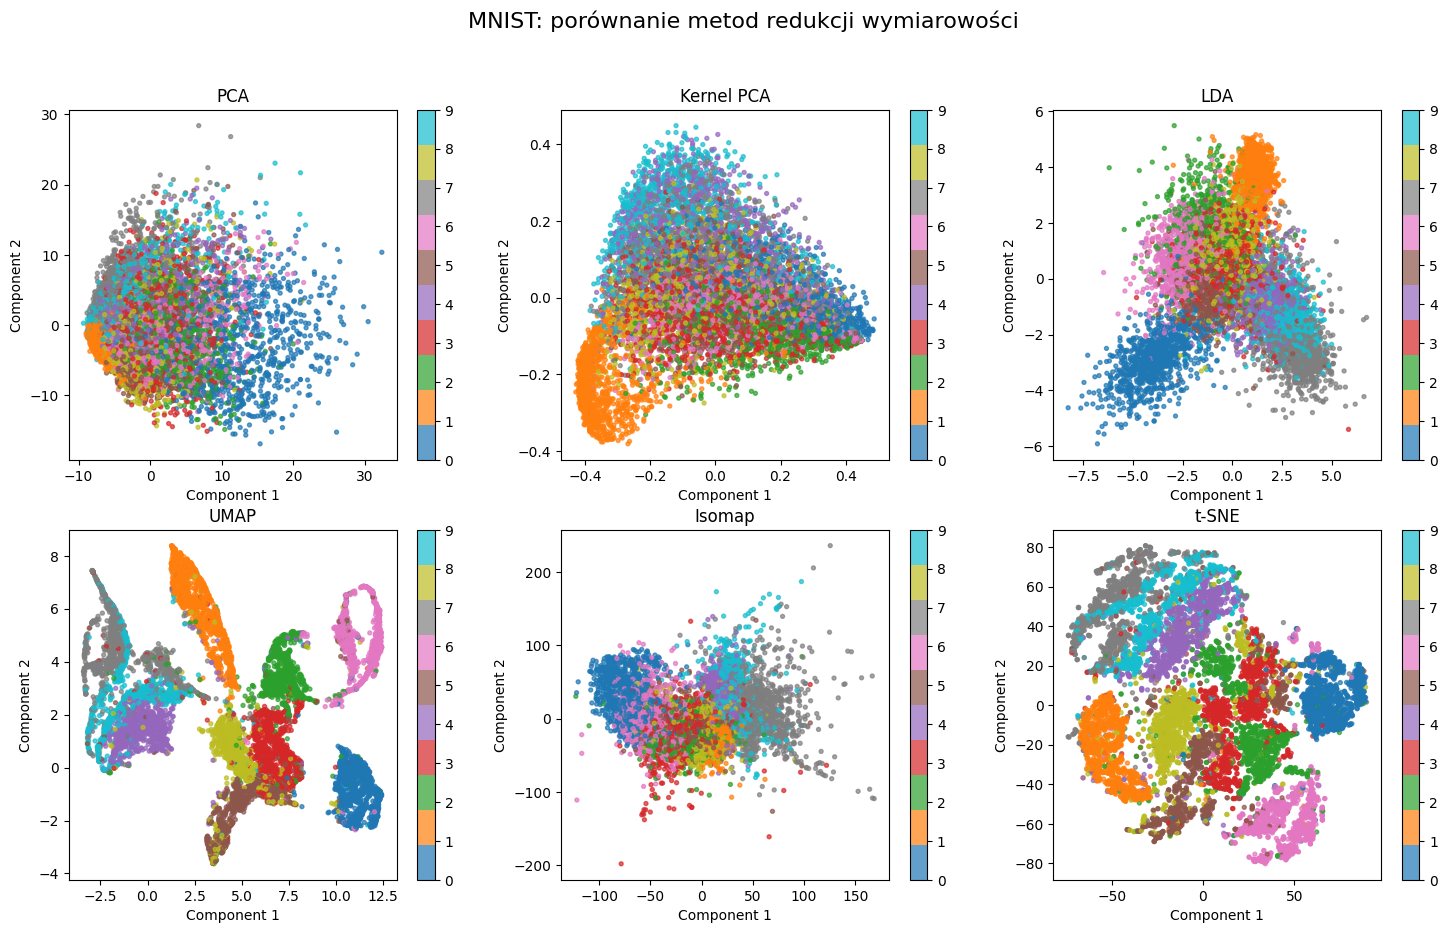

In [229]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

for ax, (name, embedding) in zip(
    axes.ravel(),
    embeddings.items()
):

    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_train,
        cmap="tab10",
        s=8,
        alpha=0.7
    )

    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

    plt.colorbar(scatter)

plt.suptitle(
    "MNIST: porównanie metod redukcji wymiarowości",
    fontsize=16
)


plt.show()

### Analiza wizualizacji

W przypadku zbioru MNIST większość metod pozwoliła na częściowe rozdzielenie poszczególnych klas cyfr, jednak stopień separacji był różny.

PCA utworzyło zwartą reprezentację danych, lecz klasy w dużym stopniu nakładają się na siebie. Pomimo tego metoda zachowała wysoką skuteczność klasyfikacji, co sugeruje, że istotna informacja została zachowana również bez wyraźnej separacji wizualnej.

Kernel PCA ujawniło bardziej złożoną strukturę danych niż klasyczne PCA, jednak nadal obserwowane jest znaczne nakładanie się części klas. Jest to zgodne z wynikami klasyfikacji, które okazały się nieco słabsze od PCA.

LDA zapewniło najlepszą separację klas spośród metod wykorzystywanych zarówno do wizualizacji, jak i klasyfikacji. Poszczególne cyfry tworzą względnie dobrze rozdzielone skupiska, co tłumaczy najwyższą skuteczność klasyfikacji po redukcji wymiarowości. Wynik ten jest naturalny, ponieważ LDA wykorzystuje informacje o etykietach klas podczas wyznaczania nowych wymiarów.

UMAP wygenerował bardzo wyraźnie odseparowane skupiska odpowiadające poszczególnym cyfrom. Metoda dobrze zachowuje lokalną strukturę danych i pozwala na intuicyjną wizualizację podobieństw pomiędzy obserwacjami.

Isomap również utworzył rozłączne grupy obserwacji, jednak granice pomiędzy niektórymi klasami pozostają mniej wyraźne niż w przypadku UMAP.

Najlepszą wizualną separację klas zapewnił t-SNE. Poszczególne cyfry tworzą dobrze wyodrębnione skupiska, a podobne cyfry znajdują się blisko siebie. Potwierdza to, że t-SNE jest szczególnie użytecznym narzędziem do eksploracyjnej analizy i wizualizacji danych wysokowymiarowych.

### Wnioski końcowe

Wyniki pokazują, że metoda zapewniająca najlepszą wizualizację nie musi prowadzić do najlepszych wyników klasyfikacji. t-SNE oraz UMAP tworzą najbardziej czytelne reprezentacje dwuwymiarowe, natomiast najwyższą skuteczność klasyfikacji po redukcji wymiarowości osiągnęło LDA. Oznacza to, że kryteria dobrej wizualizacji i dobrej reprezentacji dla klasyfikatora nie są tożsame.

W przeciwieństwie do zbioru Pima, w którym redukcja wymiarowości prowadziła do wyraźnego pogorszenia wyników, dla MNIST możliwe było zmniejszenie liczby cech z 784 do 9 przy zachowaniu wysokiej skuteczności klasyfikacji. Sugeruje to, że dane obrazowe zawierają znaczną redundancję, którą można skutecznie usunąć za pomocą metod redukcji wymiarowości.

# Dodatkowe analizy metod redukcji wymiarowości

## Zbiór danych MNIST

### <font color="blue">Principal Component Analysis - PCA</font>

In [78]:
def rysuj(x):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(14, 5.5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter3D(x[0], x[1], x[2],
              c = y_train, marker='o', alpha=0.6, s=8)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.set_zlabel("PC3")
    ax1.set_title("PCA 3D - MNIST")
    ax2 = fig.add_subplot(122)
    ax2.scatter(x[0], x[1], c = y_train, 
            marker='o', alpha=0.6, s=8)
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_title("PCA 2D - MNIST")
    plt.tight_layout()
    plt.show()

In [79]:
mnist_train = datasets.MNIST(root="./datasets", train=True, download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, download=True)

In [80]:
x_train_raw = mnist_train.data.numpy()
x_train_flat = x_train_raw.reshape(60000, 28 * 28)
x_test_raw = mnist_test.data.numpy()
x_test_flat = x_test_raw.reshape(10000, 28 * 28)
y_train = mnist_train.targets.numpy()  # Kształt: (60000,)
y_test = mnist_test.targets.numpy()    # Kształt: (10000,)
train_index = range(0,len(x_train_flat))

In [81]:
from sklearn.decomposition import PCA
n_components = 784
whiten = False
random_state = 54
pca = PCA(n_components=n_components, whiten = whiten, random_state = random_state)

In [82]:
X_train_PCA = pca.fit_transform(x_train_flat)
X_test_PCA = pca.fit_transform(x_test_flat)
X_train_PCA = pd.DataFrame(X_train_PCA, index = train_index)

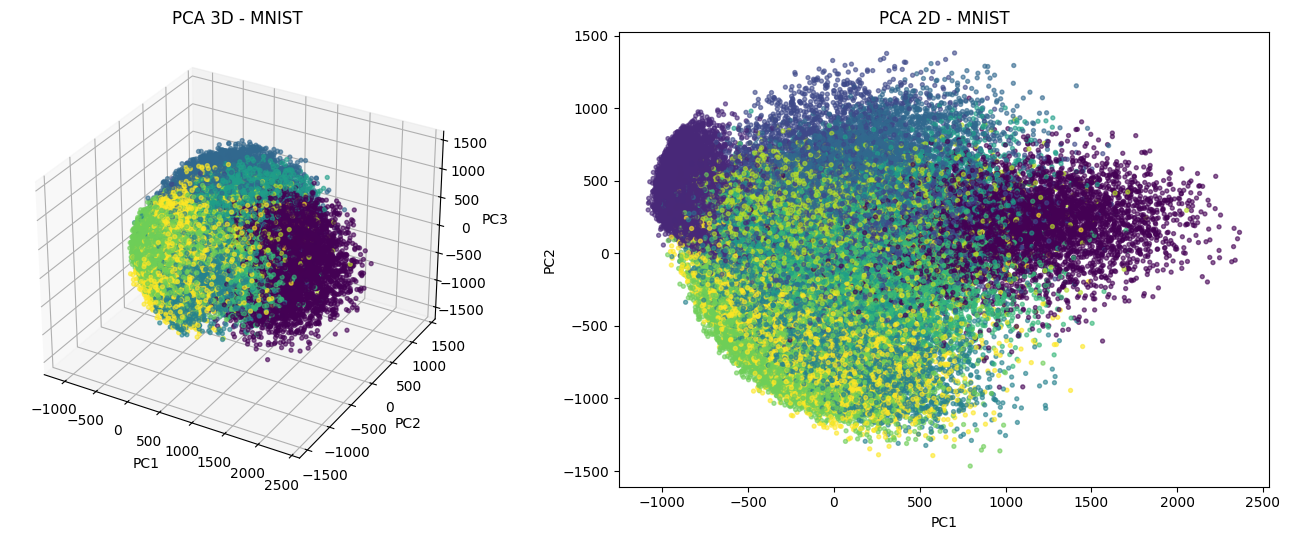

In [83]:
rysuj(X_train_PCA)

In [84]:
n_components = 2
pca = PCA(n_components=n_components, whiten = whiten, random_state = random_state)
X_train_PCA = pca.fit_transform(x_train_flat)
X_test_PCA = pca.fit_transform(x_test_flat)
X_train_PCA = pd.DataFrame(X_train_PCA, index = train_index)

### Testujemy regresję logistyczną na danych o zredukowanym wymiarze

In [85]:
n_components = 2
pca = PCA(n_components=n_components, whiten = whiten, random_state = random_state)
X_train_PCA = pca.fit_transform(x_train_flat)
X_test_PCA = pca.fit_transform(x_test_flat)
X_train_PCA = pd.DataFrame(X_train_PCA, index = train_index)

In [86]:
reg_log = LogisticRegression(random_state=0,max_iter=10000).fit(X_train_PCA, y_train)
pred_reg_log = reg_log.predict(X_test_PCA)
acc_red = accuracy_score(y_test, pred_reg_log, normalize=True)
f1_red = f1_score(y_test, pred_reg_log, average = 'weighted')

In [87]:
ramka = pd.DataFrame({"Redukcja" : [acc_red,f1_red]}, index=["Accuracy", "F1_score"])
ramka

,Redukcja
Accuracy,0.442100
F1_score,0.390479


<Axes: >

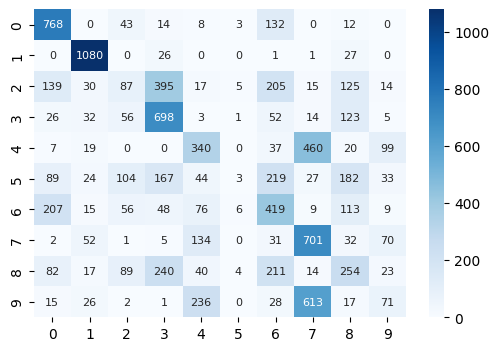

In [88]:
#Macierz pomyłek dla klasyfikacji na danych o zredukowanym wymiarze.
macierz_pomylek = confusion_matrix(y_test, pred_reg_log)
plt.figure(figsize=(6,4))
sns.heatmap(macierz_pomylek, annot=True, cmap='Blues',fmt='d', annot_kws={"size": 8})

## <font color="blue">Autoenkoder</font>

In [89]:
input_dim = x_train_flat.shape[1]  # 50 wymiarów
encoding_dim = 2
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='linear')(input_layer)
encoder = Model(inputs=input_layer, outputs=encoded)
X_train_reduced = encoder.predict(x_train_flat)
X_test_reduced = encoder.predict(x_test_flat)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step


In [90]:
X = [X_train_reduced[i][0] for i in range(len(X_train_reduced))]
Y = [X_train_reduced[i][1] for i in range(len(X_train_reduced))]

In [91]:
from sklearn.decomposition import PCA
n_components = 2
whiten = False
random_state = 54
train_index = range(0,len(x_train_flat))
pca = PCA(n_components=n_components, whiten = whiten, random_state = random_state)

In [92]:
X_train_PCA = pca.fit_transform(x_train_flat)
X_train_PCA = pd.DataFrame(X_train_PCA, index = train_index)

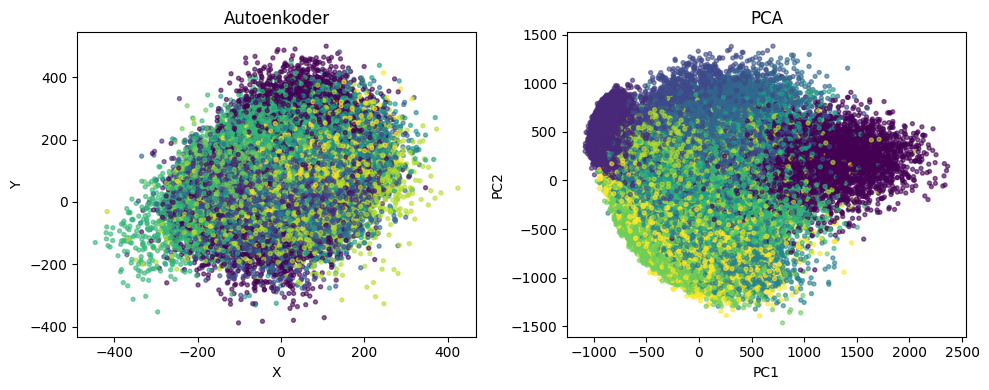

In [93]:
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.scatter(X, Y, marker='o', alpha=0.6, s=8, c = y_train)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title("Autoenkoder")
ax2 = fig.add_subplot(122)
ax2.scatter(X_train_PCA[0], X_train_PCA[1], marker='o', alpha=0.6, s=8, c = y_train)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("PCA")
plt.tight_layout()
plt.show()

### Testujemy regresję logistyczną na danych o zredukowanym wymiarze

In [94]:
reg_log = LogisticRegression(random_state=0,max_iter=10000).fit(X_train_reduced, y_train)
pred_reg_log = reg_log.predict(X_test_reduced)
acc_red_enk = accuracy_score(y_test, pred_reg_log, normalize=True)
f1_red_enk = f1_score(y_test, pred_reg_log, average = 'weighted')

In [95]:
ramka = pd.DataFrame({"Autoenkoder" : [acc_red_enk,f1_red_enk], "PCA" : [acc_red,f1_red]}, index=["Accuracy", "F1_score"])
ramka

,Autoenkoder,PCA
Accuracy,0.20540,0.442100
F1_score,0.18421,0.390479


<Axes: >

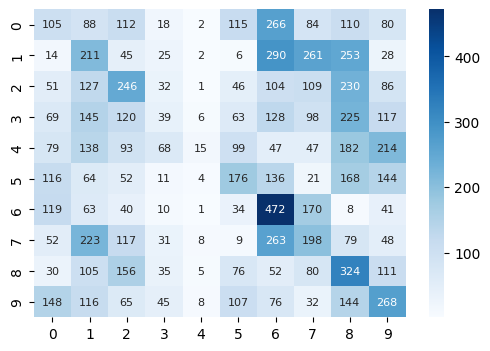

In [96]:
#Macierz pomyłek dla klasyfikacji na danych o zredukowanym wymiarze dla Autoenkodera.
macierz_pomylek = confusion_matrix(y_test, pred_reg_log)
plt.figure(figsize=(6,4))
sns.heatmap(macierz_pomylek, annot=True, cmap='Blues',fmt='d', annot_kws={"size": 8})

### <font color="blue">Linear discriminant analysis - LDA</font>

In [72]:
clf = LinearDiscriminantAnalysis(n_components = 2)
X_red = clf.fit_transform(x_train_flat, y_train)
X_red_test = clf.transform(x_test_flat) #Zwykła transformacja bez dopasowania.

In [73]:
X_red_X1 = [X_red[i][0] for i in range(len(X_red))]
X_red_X2 = [X_red[i][1] for i in range(len(X_red))]

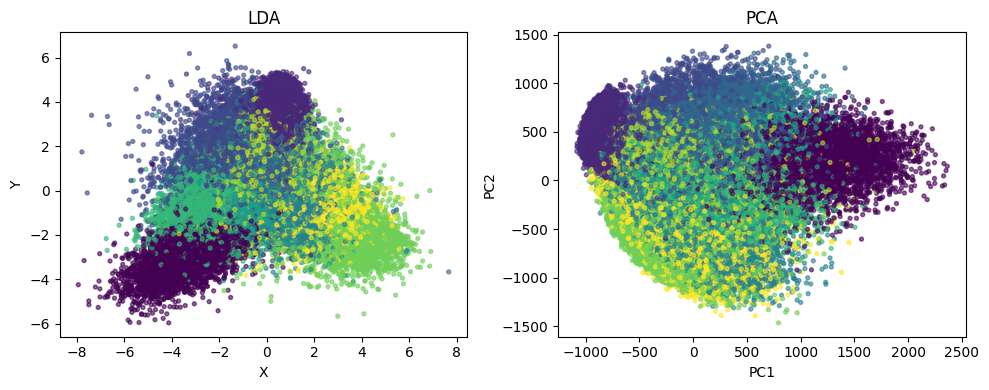

In [74]:
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(121)
ax1.scatter(X_red_X1, X_red_X2, marker='o', alpha=0.6, s=8, c = y_train)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title("LDA")
ax2 = fig.add_subplot(122)
ax2.scatter(X_train_PCA[0], X_train_PCA[1], marker='o', alpha=0.6, s=8, c = y_train)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("PCA")
plt.tight_layout()
plt.show()

### Predykcja za pomocą LDA

In [76]:
pred_lda= clf.predict(x_test_flat)
acc_red_lda = accuracy_score(y_test, pred_lda, normalize=True)
f1_red_lda = f1_score(y_test, pred_lda, average = 'weighted')

In [77]:
ramka = pd.DataFrame({"LDA" : [acc_red_lda,f1_red_lda]}, index=["Accuracy", "F1_score"])
ramka

,LDA
Accuracy,0.873000
F1_score,0.872678


## Dane syntetyczne

In [115]:
np.random.seed(42)
X, y = make_gaussian_quantiles(n_samples=1000, n_features=3, n_classes=3)
X1, y1 = make_classification(n_samples=1000, n_features=3, n_redundant=0, 
                           n_informative=3, n_clusters_per_class=1 ,n_classes=3)
Z1 = [X[i][0] for i in range(len(X))]
Z2 = [X[i][1] for i in range(len(X))]
Z3 = [X[i][2] for i in range(len(X))]
V1 = [X1[i][0] for i in range(len(X1))]
V2 = [X1[i][1] for i in range(len(X1))]
V3 = [X1[i][2] for i in range(len(X1))]
X = pd.DataFrame({"Z1" : Z1, "Z2" : Z2})
X1 = pd.DataFrame({"V1" : V1, "V2" : V2})

Text(0.5, 0.92, 'Dane do klasyfikacji')

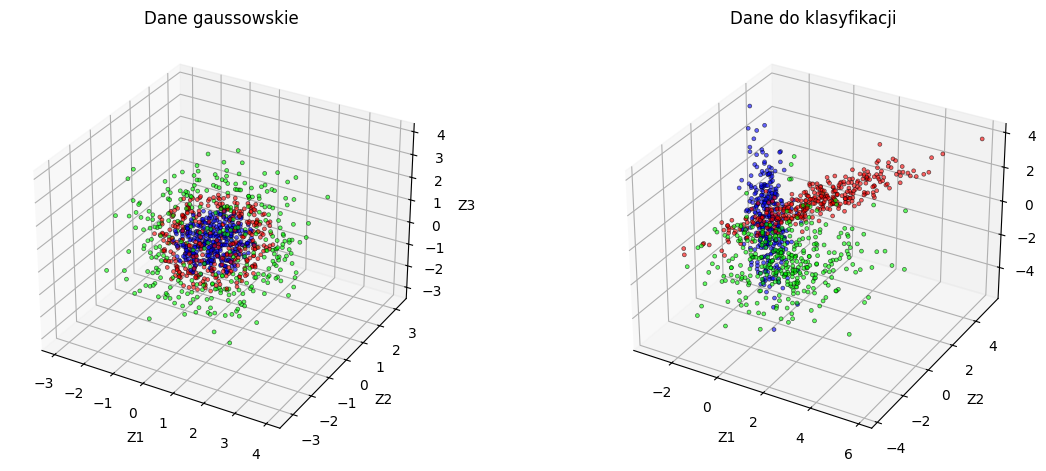

In [99]:
fig = plt.figure(figsize=(14, 5.5))
ax1 = fig.add_subplot(121,projection='3d')
ax1.scatter3D(Z1, Z2, Z3, c = y, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax1.set_xlabel("Z1")
ax1.set_ylabel("Z2")
ax1.set_zlabel("Z3")
ax1.set_title("Dane gaussowskie")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter3D(V1, V2, V3, c = y1, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax2.set_xlabel("Z1")
ax2.set_ylabel("Z2")
ax2.set_zlabel("Z3")
ax2.set_title("Dane do klasyfikacji")

In [100]:
clf = LinearDiscriminantAnalysis(n_components = 2)
X_red = clf.fit_transform(X, y)
clf2 = LinearDiscriminantAnalysis(n_components = 2)
X_red2 = clf.fit_transform(X1, y1)

In [101]:
X_red_X1 = [X_red[i][0] for i in range(len(X_red))]
X_red_X2 = [X_red[i][1] for i in range(len(X_red))]
X_red2_X1 = [X_red2[i][0] for i in range(len(X_red2))]
X_red2_X2 = [X_red2[i][1] for i in range(len(X_red2))]

Text(0.5, 1.0, 'Dane do klasyfikacji')

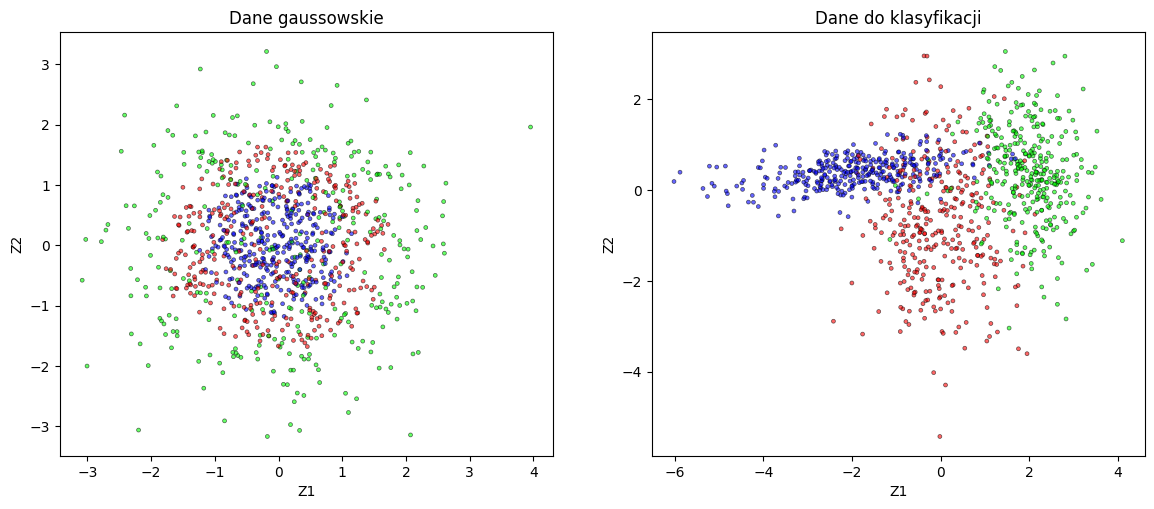

In [102]:
fig = plt.figure(figsize=(14, 5.5))
ax1 = fig.add_subplot(121)
ax1.scatter(X_red_X1, X_red_X2, c = y, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax1.set_xlabel("Z1")
ax1.set_ylabel("Z2")
ax1.set_title("Dane gaussowskie")
ax2 = fig.add_subplot(122)
ax2.scatter(X_red2_X1, X_red2_X2, c = y1, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax2.set_xlabel("Z1")
ax2.set_ylabel("Z2")
ax2.set_title("Dane do klasyfikacji")

## Dane - okręgi

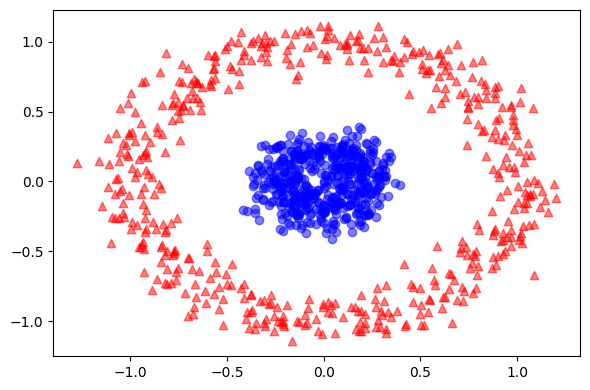

In [103]:
fig = plt.figure(figsize=(6, 4))
X, y = make_circles(n_samples = 1000, random_state = 123, noise = 0.1, factor = 0.2)
plt.scatter(X[y == 0, 0], X[y == 0, 1], color = 'red', marker = '^', alpha = 0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color = 'blue', marker = 'o', alpha = 0.5)
plt.tight_layout()
plt.show()

In [104]:
transformer = KernelPCA(n_components = 2, kernel = "rbf", gamma = 15)
X_transformed = transformer.fit_transform(X)
X_transformed = pd.DataFrame(X_transformed)

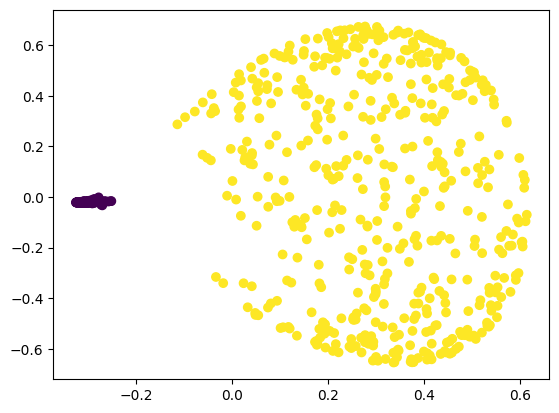

In [105]:
plt.scatter(X_transformed[0], X_transformed[1], c = y)

### Zasosowanie regresji logistycznej do danych w nowej przestrzeni

In [107]:
X_test, y_test = make_circles(n_samples = 300, random_state = 123, noise = 0.1, factor = 0.2) #Generuje zbiór testowy
transformer_test = KernelPCA(n_components = 2, kernel = "rbf", gamma = 15)
X_test_transformed = transformer.fit_transform(X_test)
X_test_transformed = pd.DataFrame(X_test_transformed)

reg_log = LogisticRegression(random_state=0,max_iter=10000).fit(X_transformed, y)
pred_reg_log = reg_log.predict(X_test_transformed)
acc_red_log = accuracy_score(y_test, pred_reg_log, normalize=True)
f1_red_log = f1_score(y_test, pred_reg_log, average = 'weighted')

In [108]:
ramka = pd.DataFrame({"KPCA" : [acc_red_log,f1_red_log]}, index=["Accuracy", "F1_score"])
ramka

,KPCA
Accuracy,0.983333
F1_score,0.983329


Osiągnięte zostały bardzo dobre wyniki. Można było się tego spodziewać patrząc na ostatni wykres.

## <font color="blue">Kernel Linear Discriminant Analysis - KLDA</font>

In [116]:
from kfda3 import Kfda
cls = Kfda(kernel='sigmoid', n_components=2)
X_klda = cls.fit_transform(X, y)

cls2 = Kfda(kernel='rbf', n_components=2)
X_klda2 = cls2.fit_transform(X1, y1)

In [117]:
X_klda_X1 = [X_klda[i][0] for i in range(len(X_klda))]
X_klda_X2 = [X_klda[i][1] for i in range(len(X_klda))]
X_klda2_X1 = [X_klda2[i][0] for i in range(len(X_klda2))]
X_klda2_X2 = [X_klda2[i][1] for i in range(len(X_klda2))]

Text(0.5, 1.0, 'Dane do klasyfikacji')

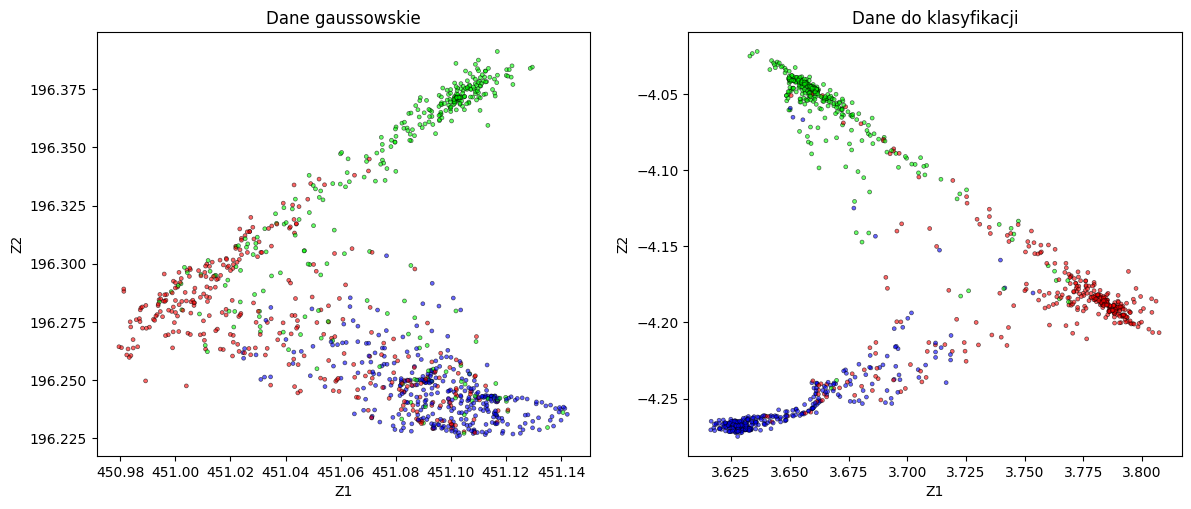

In [118]:
fig = plt.figure(figsize=(14, 5.5))
ax1 = fig.add_subplot(121)
ax1.scatter(X_klda_X1, X_klda_X2, c = y, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax1.set_xlabel("Z1")
ax1.set_ylabel("Z2")
ax1.set_title("Dane gaussowskie")
ax2 = fig.add_subplot(122)
ax2.scatter(X_klda2_X1, X_klda2_X2, c = y1, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax2.set_xlabel("Z1")
ax2.set_ylabel("Z2")
ax2.set_title("Dane do klasyfikacji")

In [119]:
#Generujemy dane testowe.
np.random.seed(42)
X_test, y_test = make_gaussian_quantiles(n_samples=300, n_features=3, n_classes=3)
X1_test, y1_test = make_classification(n_samples=300, n_features=3, n_redundant=0, 
                           n_informative=3, n_clusters_per_class=1 ,n_classes=3)
Z1 = [X_test[i][0] for i in range(len(X_test))]
Z2 = [X_test[i][1] for i in range(len(X_test))]
Z3 = [X_test[i][2] for i in range(len(X_test))]
V1 = [X1_test[i][0] for i in range(len(X1_test))]
V2 = [X1_test[i][1] for i in range(len(X1_test))]
V3 = [X1_test[i][2] for i in range(len(X1_test))]
X_test = pd.DataFrame({"Z1" : Z1, "Z2" : Z2})
X1_test = pd.DataFrame({"V1" : V1, "V2" : V2})

In [123]:
pred1 = cls.predict(X_test)
pred2 = cls2.predict(X1_test)

In [121]:
acc_red1 = accuracy_score(y_test, pred1, normalize=True)
f1_red1 = f1_score(y_test, pred1, average = 'weighted')

In [122]:
ramka = pd.DataFrame({"KLDA" : [acc_red1,f1_red1]}, index=["Accuracy", "F1_score"])
ramka

,KLDA
Accuracy,0.750000
F1_score,0.748936


In [124]:
acc_red2 = accuracy_score(y1_test, pred2, normalize=True)
f1_red2 = f1_score(y1_test, pred2, average = 'weighted')

In [125]:
ramka = pd.DataFrame({"KLDA" : [acc_red2,f1_red2]}, index=["Accuracy", "F1_score"])
ramka

,KLDA
Accuracy,0.346667
F1_score,0.290059


## <font color="blue">Isomap</font>

In [126]:
X, y = make_gaussian_quantiles(n_samples=1000, n_features=10, n_classes=2)
X1, y1 = make_classification(n_samples=1000, n_features=10, n_redundant=0, 
                           n_informative=3, n_clusters_per_class=1 ,n_classes=3)

In [127]:
embedding1 = Isomap(n_components=2)
X_transformed1 = embedding1.fit_transform(X)
embedding2 = Isomap(n_components=2)
X_transformed2 = embedding2.fit_transform(X1)

In [128]:
x1_iso = [X_transformed1[i][0] for i in range(len(X_transformed1))]
x2_iso = [X_transformed1[i][1] for i in range(len(X_transformed1))]
x1_iso2 = [X_transformed2[i][0] for i in range(len(X_transformed2))]
x2_iso2 = [X_transformed2[i][1] for i in range(len(X_transformed2))]

Text(0.5, 1.0, 'Dane do klasyfikacji')

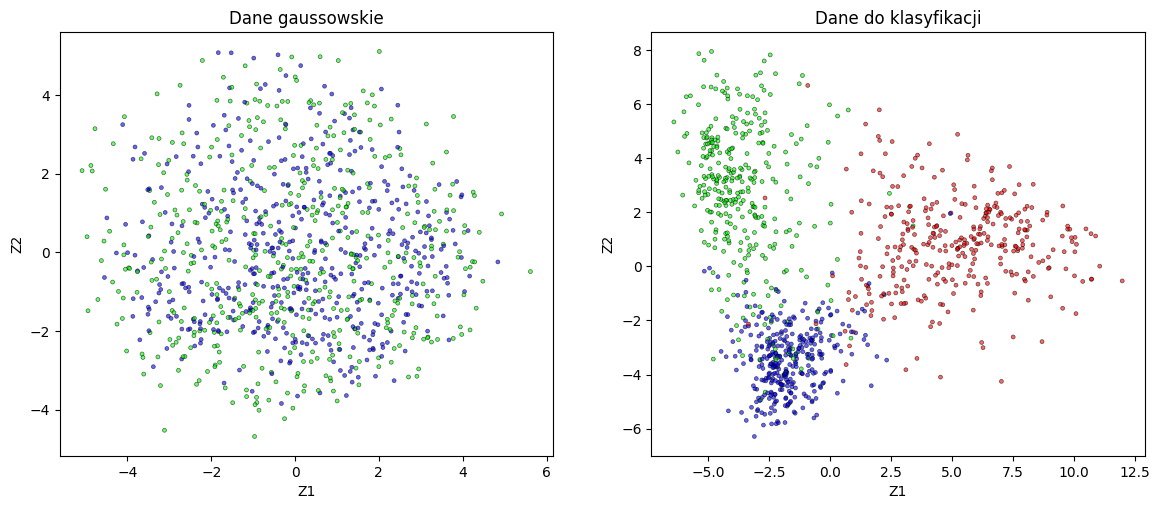

In [129]:
fig = plt.figure(figsize=(14, 5.5))
ax1 = fig.add_subplot(121)
ax1.scatter(x1_iso, x2_iso, c = y, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax1.set_xlabel("Z1")
ax1.set_ylabel("Z2")
ax1.set_title("Dane gaussowskie")

ax2 = fig.add_subplot(122)
ax2.scatter(x1_iso2, x2_iso2, c = y1, marker='o', alpha=0.6, s=8, cmap = "brg", edgecolors='black',linewidths=0.5)
ax2.set_xlabel("Z1")
ax2.set_ylabel("Z2")
ax2.set_title("Dane do klasyfikacji")

## Podsumowanie

Celem tej części było dodatkowe przedstawienie działania wcześniej omawianych metod, na nowych zbiorach danych oraz pokazanie różnych dodatkowych wizualizacji danych w nowej przestrzeni po zredukowaniu wymiaru.